# CNN AlexNet & VGG16

## Εγκατάσταση των Απαραίτητων Βιβλιοθηκών

In [1]:
%pip install torch
%pip install torchvision
%pip install numpy
%pip install scipy
%pip install scikit-learn
%pip install keras==2.4.3
%pip install tensorflow-macos
%pip3 install --upgrade alexnet_pytorch

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached Keras-2.4.3-py2.py3-none-any.whl (36 kB)
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-macos 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 2.4.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)
  Att

UsageError: Line magic function `%pip3` not found.


## Φόρτωση των Απαραίτητων Βιβλιοθηκών

In [5]:
import os
import random
import cv2
import scipy
import torch
import shutil
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from alexnet_pytorch import AlexNet

## Φόρτωση του Προεκπαιδευμένου Μοντέλου AlexNet

In [6]:
from alexnet_pytorch import AlexNet
model = AlexNet.from_pretrained('alexnet', num_classes=101)
print('AlexNet', model)

Loaded pretrained weights for alexnet
AlexNet AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_

## Εμφάνιση Όλων των Αρχείων των Κατηγοριών 

In [7]:
data_path = '/Users/marina/Python/CNN/101_ObjectCategories'
for root, dirs, files in os.walk(data_path):
    print(f'Φάκελος: {root}')
    print(f'Υποφάκελοι: {dirs}')
    print(f'Αρχεία: {files}')
    print('-----------------')

Φάκελος: /Users/marina/Python/CNN/101_ObjectCategories
Υποφάκελοι: ['gerenuk', 'hawksbill', 'headphone', 'ant', 'butterfly', 'lamp', 'strawberry', 'water_lilly', 'chandelier', 'dragonfly', 'crab', 'pagoda', 'dollar_bill', 'emu', 'inline_skate', 'platypus', 'dalmatian', 'cup', 'airplanes', 'joshua_tree', 'cougar_body', 'grand_piano', 'trilobite', 'brontosaurus', 'wild_cat', 'pigeon', 'dolphin', 'soccer_ball', 'wrench', 'scorpion', 'flamingo_head', 'nautilus', 'accordion', 'cougar_face', 'pyramid', 'camera', 'barrel', 'schooner', 'cellphone', 'panda', 'revolver', 'lobster', 'menorah', 'lotus', 'stapler', 'crocodile', 'chair', 'helicopter', 'minaret', 'starfish', 'ceiling_fan', 'ketch', 'mayfly', 'wheelchair', 'bass', 'yin_yang', 'crocodile_head', 'saxophone', 'beaver', 'mandolin', 'bonsai', 'Leopards', 'car_side', 'ibis', 'electric_guitar', 'kangaroo', 'stegosaurus', 'ferry', 'snoopy', 'umbrella', 'rhino', 'okapi', 'watch', 'brain', 'gramophone', 'scissors', 'rooster', 'cannon', 'binocul

## Φόρτωση των Αρχείων .mat

In [8]:
def load_annotations(annotations_path):
    annotations = []
    
    for file in os.listdir(annotations_path):
        if file.endswith('.mat'):
            mat_file = scipy.io.loadmat(os.path.join(annotations_path, file))
            data = {
                'file_list': mat_file.get('file_list'),
                'box_coord': mat_file.get('box_coord'),
                'obj_contour': mat_file.get('obj_contour')
            }
            annotations.append(data)
    
    return annotations

annotations_path = '/Users/marina/Python/CNN/Annotations'
annotations_data = load_annotations(annotations_path)

## Εμφάνιση Όλων των Εικόνων της Κάθε Κατηγορίας

In [6]:
def show_images(image_folder):
    for root, dirs, files in os.walk(image_folder):
        for file in files:
            if file.lower().endswith('.jpg'):
                image_path = os.path.join(root, file)
                image = cv2.imread(image_path)
                if image is not None:
                    cv2.imshow('Image', image)
                    cv2.waitKey(0)
                    cv2.destroyAllWindows()
                else:
                    print(f"Unable to read image: {image_path}")

image_folder = '/Users/marina/Python/CNN/101_ObjectCategories'
show_images(image_folder)

2024-01-30 21:31:50.659 Python[23655:291472] WARNING: Secure coding is not enabled for restorable state! Enable secure coding by implementing NSApplicationDelegate.applicationSupportsSecureRestorableState: and returning YES.


## Διαχωρισμός του Dataset

In [9]:
data_path = '/Users/marina/Python/CNN/101_ObjectCategories'
train = '/Users/marina/Python/CNN/train'
test = '/Users/marina/Python/CNN/test'

def split_data_relative(data_path, train_dir, test_dir, split_size):
    output_file = 'splitdataset.txt'

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    with open(output_file, 'w') as file:
        for root, dirs, files in os.walk(data_path):
            if not files or not any(file.lower().endswith('.jpg') for file in files):
                continue  
            category = os.path.basename(root)
            category_path = os.path.join(data_path, category)
            train_category = os.path.join(train_dir, category)
            test_category = os.path.join(test_dir, category)

            os.makedirs(train_category, exist_ok=True)
            os.makedirs(test_category, exist_ok=True)

            images = [img for img in files if img.lower().endswith('.jpg')]

            num_train = int(len(images) * split_size)
            train_images = random.sample(images, num_train)

            for img in images:
                img_path = os.path.join(root, img)
                if img in train_images:
                    shutil.copy(img_path, os.path.join(train_category, img))
                else:
                    shutil.copy(img_path, os.path.join(test_category, img))

            print(f'Train set ({category}): {len(os.listdir(train_category))} images', file=file)
            print(f'Test set ({category}): {len(os.listdir(test_category))} images', file=file)

split_data_relative(data_path, train, test, 0.7)

Τα αποτελέσματα αποθηκεύτηκαν στο αρχείο splitdataset.txt.


## Eκπαίδευση

In [ ]:
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])

full_dataset = ImageFolder(data_path, transform=transform)

train_size = int(0.7 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# AlexNet Model
model = AlexNet.from_pretrained('alexnet', num_classes=102)

# Optimize
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

# Train
for epoch in range(num_epochs):
    model.train()  
    for inputs, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item()}')

# Accuracy
model.eval() 
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Accuracy on test set: {accuracy}')

confusion_matrix = torch.zeros(102, 102)

with torch.no_grad():
    for inputs, labels in test_dataloader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        for i in range(len(predicted)):
            confusion_matrix[labels[i], predicted[i]] += 1

accuracy = correct / total
error_rate = 1 - accuracy
print(f'Accuracy on test set: {accuracy}')
print(f'Error rate on test set: {error_rate}')
print('Confusion Matrix:')
print(confusion_matrix)


Loaded pretrained weights for alexnet
Epoch [1/10], Loss: 1.3681461811065674
Epoch [2/10], Loss: 0.8261774778366089
Epoch [3/10], Loss: 0.3185969889163971
Epoch [4/10], Loss: 0.3938715159893036
Epoch [5/10], Loss: 0.021976759657263756
Epoch [6/10], Loss: 0.06640349328517914
Epoch [7/10], Loss: 0.00606967369094491
Epoch [8/10], Loss: 0.46444398164749146
Epoch [9/10], Loss: 0.002870225813239813
Epoch [10/10], Loss: 0.29784348607063293
Accuracy on test set: 0.8560495626822158
Accuracy on test set: 0.8560495626822158
Error rate on test set: 0.14395043731778423
Confusion Matrix:
tensor([[ 84.,   0.,   0.,  ...,   0.,   0.,   1.],
        [  0., 131.,   2.,  ...,   0.,   0.,   0.],
        [  0.,   1., 127.,  ...,   0.,   0.,   0.],
        ...,
        [  0.,   0.,   0.,  ...,  18.,   0.,   0.],
        [  1.,   0.,   0.,  ...,   0.,   8.,   0.],
        [  2.,   0.,   0.,  ...,   0.,   0.,  14.]])


## HeatMap

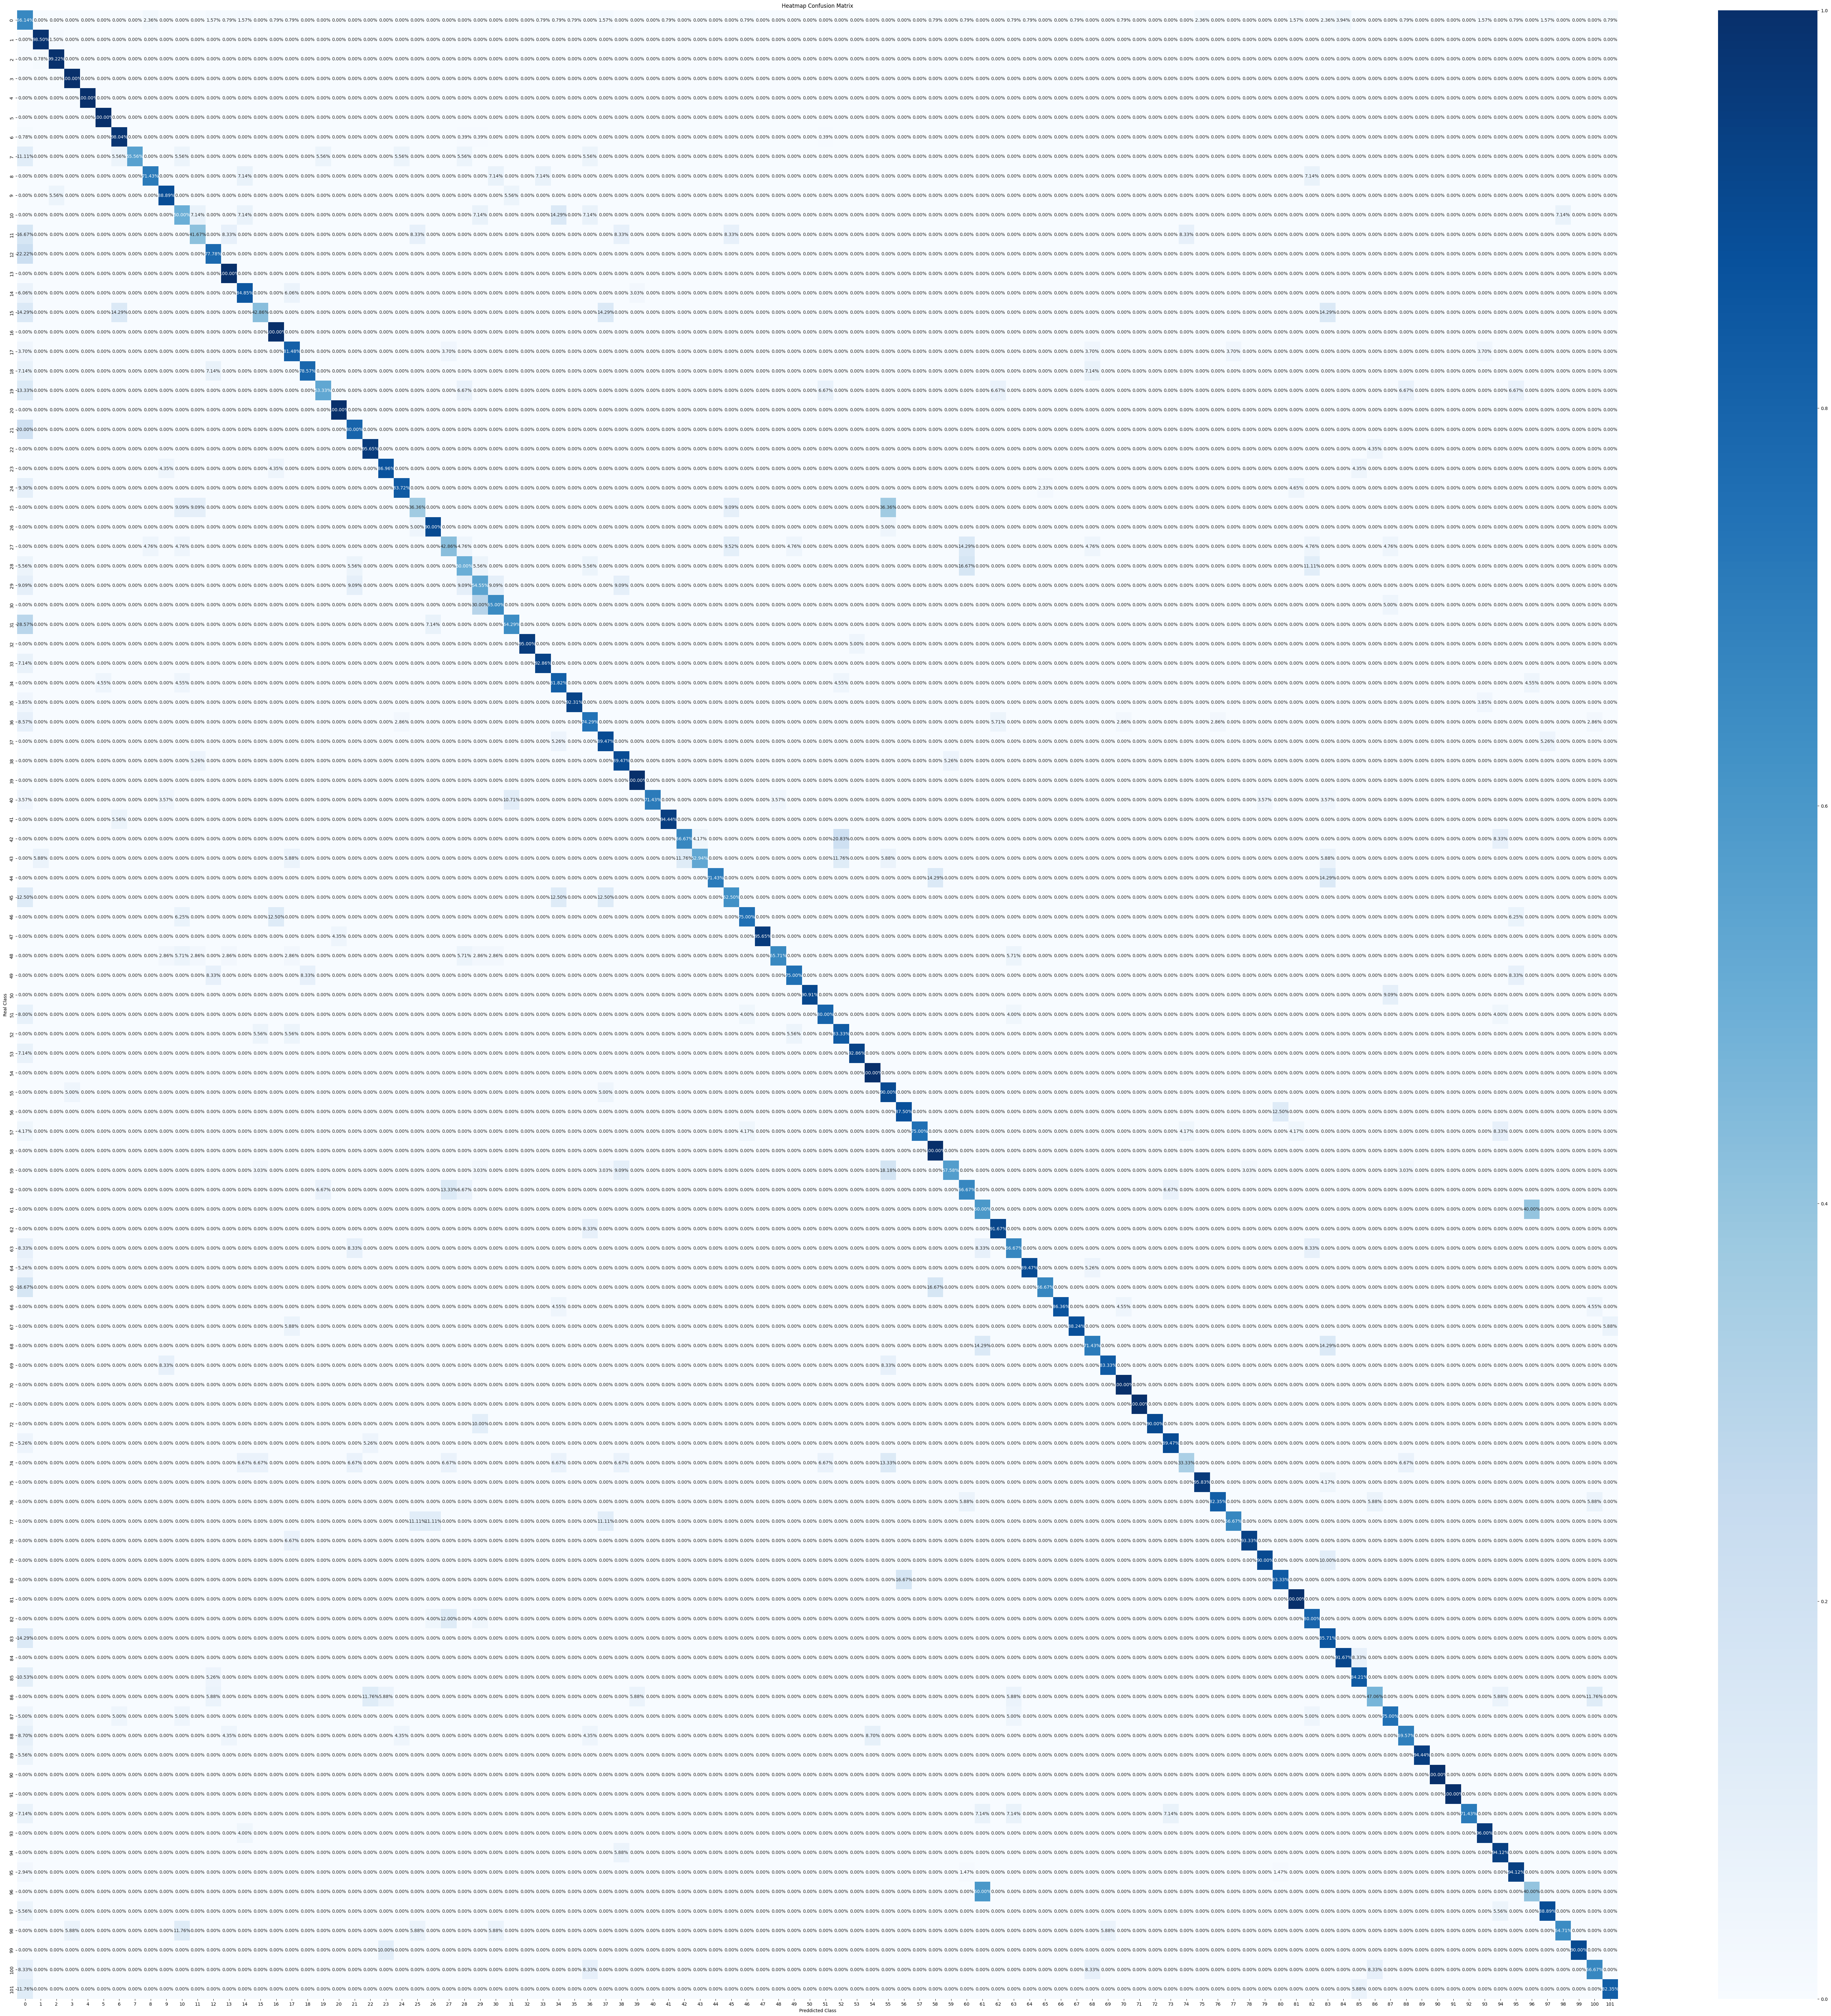

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [str(i) for i in range(102)] 
fig, ax = plt.subplots(figsize=(80, 80))
sns.heatmap(confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True), annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Preddicted Class')
plt.ylabel('Real Class')
plt.title('Heatmap Confusion Matrix')
plt.savefig('Confusion_Matrix.png')